# DetectSpam

Spam Message Detection using Machine Learning

Master's Degree in Artificial Intelligence
Universidad Icesi

Course:
Hackeando la IA

Professor:
Christian Urcuqui

Authors:
Alfredo Aponte
Arlex Pino

## Problem Statement

Spam messages continue to represent a major challenge in
electronic communications.

The objective of this project is to build a machine learning
model capable of automatically identifying spam messages.

In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/smsspam/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)

df.columns = df.columns.str.strip()

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [2]:
df.columns

Index(['label', 'message'], dtype='object')

In [3]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [4]:
df.shape
df.info()
df["label"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


label
ham     4825
spam     747
Name: count, dtype: int64

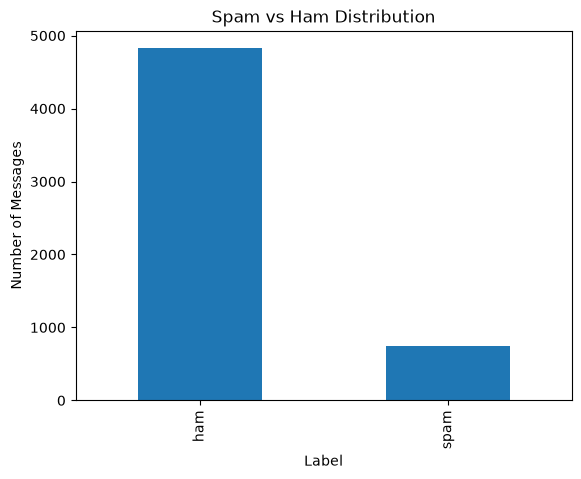

In [5]:
import matplotlib.pyplot as plt

# Calculate the number of messages per class
class_counts = df["label"].value_counts()

# Create a bar chart showing the class distribution
class_counts.plot(kind="bar")

# Add chart title and labels
plt.title("Spam vs Ham Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Messages")

# Display the chart
plt.show()

## Class Distribution Analysis

Before training a machine learning model, it is important to understand how the classes are distributed within the dataset.

The SMS Spam Collection dataset contains two categories:

- **ham**: legitimate messages (non-spam)
- **spam**: unwanted or malicious messages

The following chart illustrates the distribution of both classes.

### Observations

The dataset is significantly imbalanced.

Most messages belong to the **ham** category, while a much smaller portion corresponds to **spam** messages.

This imbalance is expected in real-world communication systems, where legitimate messages greatly outnumber spam messages.

### Implications for Machine Learning

Class imbalance can affect model performance because a classifier may become biased toward predicting the majority class.

For this reason, relying solely on **Accuracy** is not sufficient. Additional evaluation metrics such as:

- Precision
- Recall
- F1 Score

should be considered during model evaluation.

Understanding the class distribution is therefore a critical step before training the model.

## Message Length Analysis

In [6]:
# Calculate the length of each message
df["message_length"] = df["message"].apply(len)

# Display summary statistics
df["message_length"].describe()

count    5572.000000
mean       80.489950
std        59.942907
min         2.000000
25%        36.000000
50%        62.000000
75%       122.000000
max       910.000000
Name: message_length, dtype: float64

In [7]:
# Compare message lengths between ham and spam messages
df.groupby("label")["message_length"].mean()

label
ham      71.482487
spam    138.670683
Name: message_length, dtype: float64

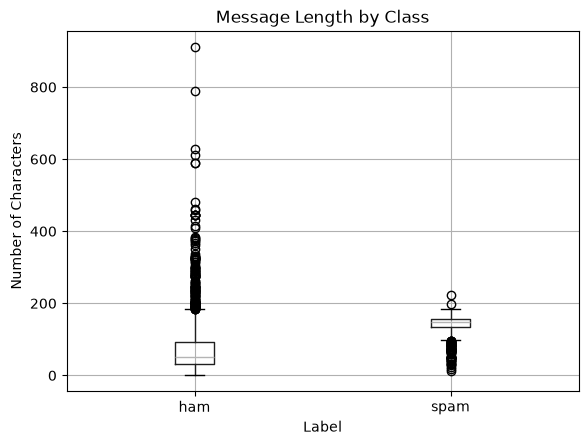

In [8]:
# Visualize message length distribution
df.boxplot(column="message_length", by="label")
plt.title("Message Length by Class")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("Number of Characters")
plt.show()

### Message Length Distribution

Message length is an important feature in spam detection because spam messages often contain additional promotional content, instructions, URLs, or calls to action.

To investigate this behavior, the length of each message was calculated as the number of characters contained in the text.

The following boxplot compares the distribution of message lengths for both classes.

### Observations

Several important patterns can be observed:

- Spam messages tend to be significantly longer than legitimate messages.
- The median length of spam messages is substantially higher than the median length of ham messages.
- Ham messages exhibit a larger number of extreme outliers.
- Some legitimate messages contain very long conversational content.

### Interpretation

The results suggest that message length may provide useful predictive information for the classification task.

Although message length alone is not sufficient to distinguish spam from non-spam messages, it can contribute valuable information when combined with textual features extracted through Natural Language Processing techniques.

### Conclusion

Message length appears to be a discriminative feature and supports the hypothesis that spam messages generally contain more content than regular personal communications.

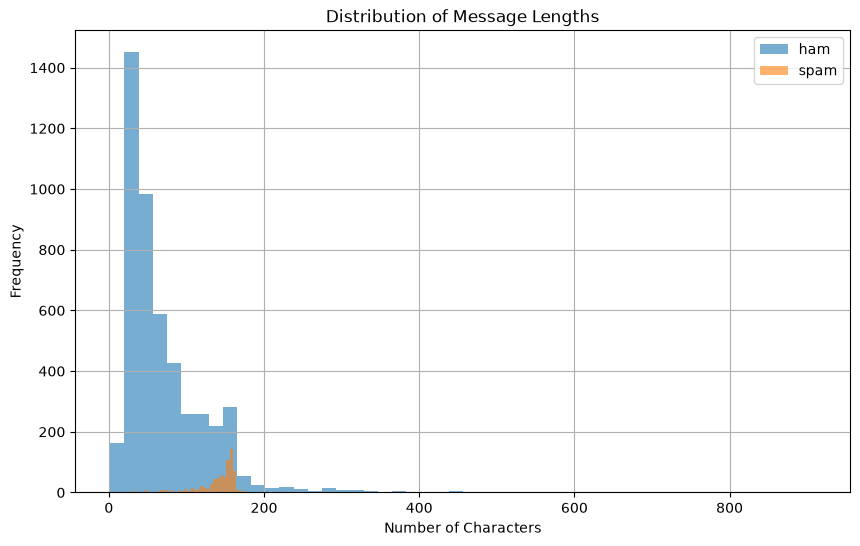

In [9]:
# Histogram of message lengths

plt.figure(figsize=(10, 6))

df[df["label"] == "ham"]["message_length"].hist(
    bins=50,
    alpha=0.6,
    label="ham"
)

df[df["label"] == "spam"]["message_length"].hist(
    bins=50,
    alpha=0.6,
    label="spam"
)

plt.title("Distribution of Message Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.legend()

plt.show()

### Additional Findings from the Length Distribution

The histogram provides a more detailed view of the underlying distributions and reveals patterns that were not visible in the previous boxplot.

### New Observations

- Ham messages exhibit a highly right-skewed distribution, with most messages concentrated at relatively short lengths.
- Spam messages are more concentrated within a narrower range of message lengths.
- The highest density of spam messages appears around the 130–170 character range.
- There is a visible overlap between both classes, indicating that message length alone cannot perfectly separate spam from non-spam messages.

### Interpretation

The overlap observed between the two distributions suggests that message length should not be used as a standalone classification criterion.

Instead, it should be combined with textual features extracted from the message content, allowing the model to leverage both structural and semantic information.

### Conclusion

The histogram confirms that message length contributes useful predictive information; however, additional text-based features are required to achieve robust spam detection performance.

## Most Frequent Words Analysis

In [10]:
from collections import Counter
import re

# Create separate corpora
ham_messages = " ".join(df[df["label"] == "ham"]["message"])
spam_messages = " ".join(df[df["label"] == "spam"]["message"])

# Basic tokenizer
def tokenize(text):
    text = text.lower()
    return re.findall(r"\b[a-z]+\b", text)

ham_tokens = tokenize(ham_messages)
spam_tokens = tokenize(spam_messages)

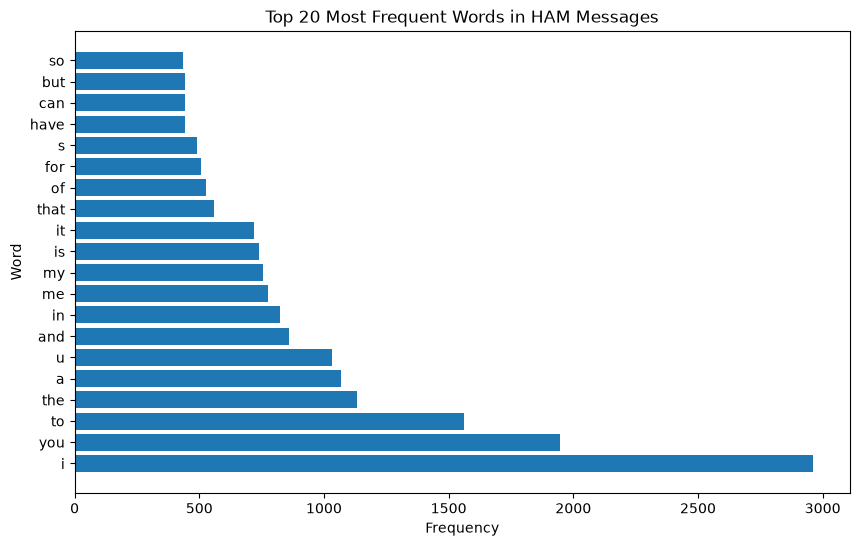

In [11]:
ham_top_words = Counter(ham_tokens).most_common(20)

ham_words = [word for word, count in ham_top_words]
ham_counts = [count for word, count in ham_top_words]

plt.figure(figsize=(10,6))

plt.barh(ham_words, ham_counts)

plt.title("Top 20 Most Frequent Words in HAM Messages")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

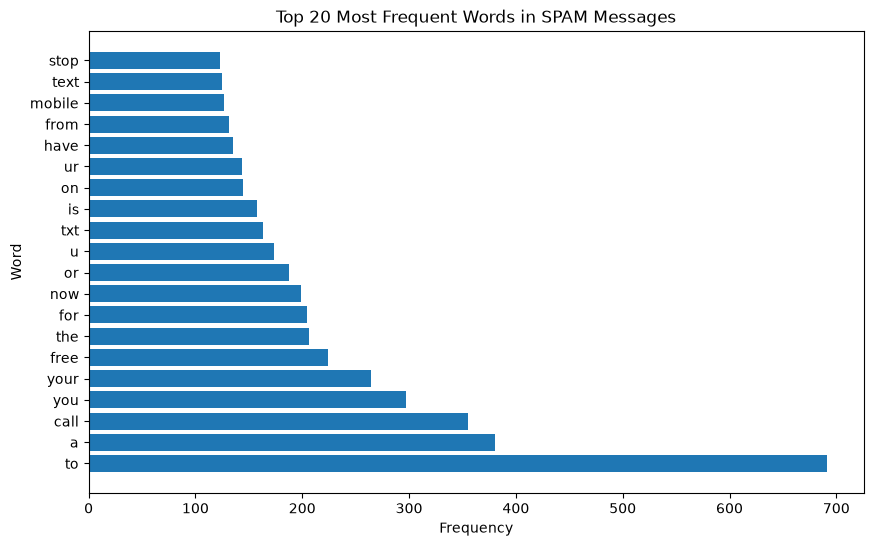

In [12]:
spam_top_words = Counter(spam_tokens).most_common(20)

spam_words = [word for word, count in spam_top_words]
spam_counts = [count for word, count in spam_top_words]

plt.figure(figsize=(10,6))

plt.barh(spam_words, spam_counts)

plt.title("Top 20 Most Frequent Words in SPAM Messages")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

## Frequent Word Analysis

The most frequent words were analyzed separately for ham and spam messages to better understand the vocabulary used in each category.

### New Observations

- The ham messages are dominated by common conversational terms such as "i", "you", "to", "the", and "u".
- The spam messages contain several action-oriented terms, including "call", "free", "txt", "mobile", and "stop".
- Many highly frequent words appear in both classes, including "to", "you", and "the".
- The presence of common words across both categories indicates that raw word frequency alone is insufficient for accurate classification.

### Interpretation

The overlap between frequent words in both classes suggests that not all words contribute equally to the prediction task.

Words such as "free", "call", "txt", and "mobile" appear to carry stronger discriminative information than highly common conversational terms.

This observation motivates the use of feature weighting techniques such as TF-IDF, which reduce the importance of overly frequent words while emphasizing more informative terms.

### Conclusion

The vocabulary analysis highlights the need for feature engineering techniques capable of distinguishing informative terms from common language patterns. This provides a strong justification for applying TF-IDF vectorization before training the classification model.

## Text Preprocessing

## Feature Engineering with TF-IDF

Machine learning algorithms cannot process raw text directly. Therefore, the cleaned messages must be transformed into numerical features.

For this project, TF-IDF vectorization was used.

TF-IDF stands for Term Frequency-Inverse Document Frequency. It assigns higher importance to words that are frequent in a specific message but not overly common across the entire dataset.

This is useful for spam detection because certain words such as "free", "call", "txt", or "mobile" may be more informative than general conversational words.

In [13]:
import sys
from pathlib import Path

# Add the project root directory to the Python path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

# Import the preprocessing function used by the application
from app.ml.preprocessing import clean_text

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Apply text preprocessing to all messages
df["clean_message"] = df["message"].apply(clean_text)

# Create the TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Transform cleaned text messages into numerical features
X = tfidf_vectorizer.fit_transform(df["clean_message"])

# Target variable
y = df["label"]

# Display the shape of the resulting feature matrix
X.shape

(5572, 8709)

### TF-IDF Matrix Interpretation

After applying TF-IDF vectorization, the dataset was transformed into a numerical matrix with **5,572 rows** and **8,709 columns**.

- Each row represents one SMS message.
- Each column represents a unique term identified by the TF-IDF vectorizer.
- The value in each cell represents the relative importance of a term within a specific message.

This confirms that the text data has been successfully transformed into a numerical format suitable for machine learning model training.

## Train-Test Split

Before training the model, the dataset is divided into two subsets:

- Training Set: used to learn patterns from the data.
- Test Set: used to evaluate the model on previously unseen messages.

This separation helps estimate how well the model generalizes to new data and reduces the risk of overfitting.

In [15]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display dataset sizes
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 4457
Testing samples : 1115


### Train-Test Split Results

The dataset was divided using an 80/20 ratio.

The training subset is used to fit the machine learning model, while the testing subset is reserved for performance evaluation.

Using a fixed random seed (`random_state=42`) ensures that the experiment can be reproduced consistently.

## Model Training

After transforming the text messages into numerical features, a machine learning model can be trained.

For this project, the Multinomial Naive Bayes classifier was selected due to its effectiveness in text classification problems and its computational efficiency.

The model learns the statistical relationship between terms and message categories, allowing it to predict whether a new message is spam or not.

In [16]:
from sklearn.naive_bayes import MultinomialNB

# Create the classifier
model = MultinomialNB()

# Train the model
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


### Training Summary

The Multinomial Naive Bayes algorithm was trained using the TF-IDF feature matrix generated during the preprocessing stage.

This algorithm is particularly well suited for text classification tasks because it models the probability distribution of words across different classes.

In [17]:
from sklearn.metrics import accuracy_score

# Generate predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9605


## Model Evaluation

To evaluate the effectiveness of the classifier, predictions were generated on the testing dataset and compared against the true labels.

### Accuracy Result

The model achieved an accuracy of **96.05%** on previously unseen messages.

This result indicates that the classifier correctly identified the class of most messages in the testing dataset.

However, accuracy alone does not provide a complete view of model performance, especially in imbalanced datasets such as spam detection. Therefore, additional metrics including Precision, Recall, and F1 Score should also be evaluated.

In [18]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
)

precision = precision_score(
    y_test,
    y_pred,
    pos_label="spam"
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label="spam"
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label="spam"
)

print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Precision: 1.0000
Recall   : 0.7047
F1 Score : 0.8268


### Precision, Recall and F1 Score Analysis

Additional evaluation metrics were calculated to obtain a more comprehensive understanding of model performance.

| Metric | Value |
|----------|----------|
| Precision | 100.00% |
| Recall | 70.47% |
| F1 Score | 82.68% |

### New Observations

- The model achieved perfect precision, meaning that every message classified as spam was actually spam.
- The recall value is noticeably lower than the precision value, indicating that some spam messages were not detected.
- The F1 Score reflects the balance between precision and recall, providing a more representative measure of performance than accuracy alone.

### Interpretation

The classifier adopts a conservative strategy when predicting spam messages.

While this behavior minimizes false positive classifications, it also increases the likelihood of missing certain spam messages.

This trade-off may be desirable in applications where incorrectly flagging legitimate messages is considered more costly than allowing some spam messages to pass through.

### Conclusion

The evaluation results demonstrate that the model is highly reliable when identifying spam messages. However, future improvements should focus on increasing recall while preserving the high precision currently achieved.

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["ham", "spam"]
)

print(cm)

[[966   0]
 [ 44 105]]


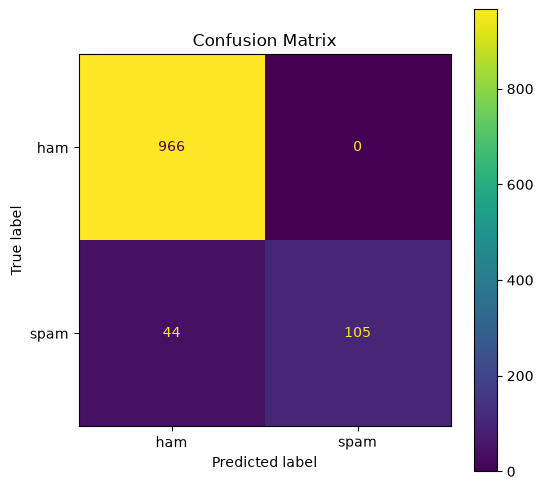

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create the figure and axis to avoid generating an empty extra plot
fig, ax = plt.subplots(figsize=(6, 6))

# Create the confusion matrix visualization using the existing confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["ham", "spam"]
)

# Plot the confusion matrix on the defined axis
disp.plot(ax=ax)

# Add chart title
plt.title("Confusion Matrix")

# Display the final chart
plt.show()

## Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of prediction outcomes and helps identify the types of classification errors made by the model.

### New Observations

| Outcome | Count |
|----------|----------|
| True Negatives | 966 |
| False Positives | 0 |
| False Negatives | 44 |
| True Positives | 105 |

### Interpretation

The model correctly classified all legitimate messages, resulting in zero false positives.

This behavior confirms the perfect precision observed during evaluation.

However, the model failed to identify 44 spam messages, which contributes to the lower recall score.

The confusion matrix reveals that the primary source of error comes from spam messages being incorrectly classified as legitimate messages.

### Conclusion

The classifier prioritizes avoiding false alarms over maximizing spam detection coverage.

This conservative behavior is appropriate in scenarios where incorrectly blocking legitimate communications would have a significant negative impact on users.

In [21]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.70      0.83       149

    accuracy                           0.96      1115
   macro avg       0.98      0.85      0.90      1115
weighted avg       0.96      0.96      0.96      1115



## Classification Report Analysis

The classification report provides a class-level evaluation of model performance.

### New Observations

- The ham class achieved an F1 Score of 98%, indicating excellent performance when identifying legitimate messages.
- The spam class achieved an F1 Score of 83%, reflecting the impact of the missed spam messages observed in the confusion matrix.
- The weighted average F1 Score reached 96%, demonstrating strong overall predictive performance.
- The macro average F1 Score is lower than the weighted average due to the class imbalance present in the dataset.

### Interpretation

The results indicate that the model performs exceptionally well when identifying legitimate messages while maintaining strong precision for spam detection.

The lower recall for the spam class suggests that additional feature engineering or alternative algorithms could further improve detection coverage.

### Conclusion

The classification report confirms that the model generalizes effectively to unseen messages and provides a balanced performance suitable for a baseline spam detection system.

# Testing Examples

To validate the behavior of the deployed prediction pipeline, several sample messages were submitted to the classifier.

Unlike the previous evaluation metrics, these examples simulate real user interactions with the application and demonstrate how the model behaves in practical scenarios.

In [22]:
# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

# Import the same predictor used by the application
from app.services.predictor import predictor

In [23]:
test_messages = [
    "Congratulations! You won a free prize. Call now.",
    "URGENT! Claim your reward immediately.",
    "Hi, what time is the meeting tomorrow?",
    "Can you send me the document when you have time?",
    "Free entry in a weekly competition. Text WIN now."
]

for message in test_messages:
    result = predictor.predict(message)

    print("-" * 80)
    print("Message     :", message)
    print("Prediction  :", result["prediction"])
    print("Confidence  :", result["confidence"])
    print("Explanation :", result["explanation"])

--------------------------------------------------------------------------------
Message     : Congratulations! You won a free prize. Call now.
Prediction  : spam
Confidence  : 0.7949
Explanation : The message contains patterns commonly associated with spam, such as promotions, prizes, urgency, or calls to action.
--------------------------------------------------------------------------------
Message     : URGENT! Claim your reward immediately.
Prediction  : spam
Confidence  : 0.861
Explanation : The message contains patterns commonly associated with spam, such as promotions, prizes, urgency, or calls to action.
--------------------------------------------------------------------------------
Message     : Hi, what time is the meeting tomorrow?
Prediction  : ham
Confidence  : 0.9976
Explanation : The message does not contain enough characteristics typically associated with spam according to the trained model.
-----------------------------------------------------------------------------

## Testing Examples Analysis

Several representative messages were evaluated using the deployed prediction pipeline.

### New Observations

- Messages containing promotional language such as "free", "prize", "reward", and "win" were consistently classified as spam.
- Legitimate conversational messages were classified as ham with very high confidence scores, exceeding 99%.
- Spam predictions generally exhibited lower confidence values than ham predictions.
- The model successfully identified different spam patterns, including prizes, rewards, competitions, and urgent calls to action.

### Interpretation

The examples suggest that the classifier has learned meaningful associations between specific terms and the spam category.

The high confidence observed in legitimate messages indicates that the model can clearly distinguish common conversational language from promotional content.

The lower confidence associated with some spam messages may reflect the diversity of spam vocabulary and the conservative behavior previously observed during evaluation.

### Conclusion

The testing examples demonstrate that the prediction pipeline behaves consistently with the quantitative evaluation metrics and provides reasonable classifications for both legitimate and spam-oriented messages.

# Conclusions

This project successfully implemented a complete Machine Learning pipeline for spam message detection.

The Data Science workflow covered the entire lifecycle of the project, including:

- Data acquisition
- Exploratory Data Analysis (EDA)
- Text preprocessing
- Feature engineering using TF-IDF
- Model training
- Model evaluation
- Deployment through a FastAPI web application

The Multinomial Naive Bayes classifier achieved an accuracy of 96.05% on unseen messages.

Additional evaluation metrics revealed a Precision of 100.00%, a Recall of 70.47%, and an F1 Score of 82.68%.

The confusion matrix analysis showed that the classifier did not generate false positive spam detections, demonstrating a highly conservative prediction strategy.

The experimental results indicate that TF-IDF combined with Multinomial Naive Bayes provides a strong baseline solution for spam detection while maintaining computational efficiency and ease of deployment.

Overall, the project demonstrates how Machine Learning techniques can effectively support automated spam filtering in real-world communication systems.

# Future Work

Several opportunities exist to further improve the performance and capabilities of the DetectSpam system.

Potential future developments include:

- Improving recall while maintaining the current precision level.
- Evaluating alternative machine learning algorithms such as Logistic Regression, Random Forest, and Gradient Boosting.
- Experimenting with Deep Learning and Transformer-based architectures.
- Implementing Explainable AI (XAI) techniques to improve prediction transparency.
- Incorporating additional datasets to increase model robustness.
- Developing a real-time metrics dashboard for model monitoring.
- Implementing model retraining pipelines to support continuous learning.
- Exploring adversarial spam detection scenarios.

These improvements could increase detection coverage and further enhance the practical applicability of the system.